# Exploratory Analysis of Daily Burned Area in Spain (1983–2022)

This work presents an exploratory analysis of fire season properties based on spatial-temporal burned area data across Spain. Using monthly average burned area time series derived from satellite observations and other sources, we characterize the fire season by calculating key metrics such as seasonal concentration, seasonal timing, bimodality, and the length of the fire season.

The methodology involves summarizing temporal patterns through circular statistics to capture the periodic nature of fire occurrence within the year, identifying the main fire season(s), and quantifying the concentration of fire activity around specific months. Additionally, we assess bimodality to detect the presence of two distinct fire seasons within a year and estimate the duration of these seasons.

All analyses are implemented with custom functions that process monthly burned area averages for spatial grid cells, enabling regional comparisons and spatial clustering of fire regimes. The goal is to provide a detailed and reproducible characterization of the fire season dynamics in Spain, contributing to a better understanding of wildfire behavior and its spatial heterogeneity.

This approach integrates time series analysis, circular statistics, and clustering methods to extract meaningful fire season information and facilitate spatial interpretation. The entire workflow is designed to be reproducible and extensible, providing a solid foundation for further wildfire risk assessment and climate impact studies.

All steps are fully reproducible using `loadeR`, `transformeR`, and `visualizeR` packages.

In [ ]:
source("Functions.R")

Cargando paquete requerido: rJava

Cargando paquete requerido: loadeR.java

Java version 1.8x amd64 by Oracle Corporation detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Cargando paquete requerido: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.2 (2024-06-04) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.3 (2024-06-05) is loaded

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



## Downloading and Upscaling the Spatial Grid

In this section, the original spatial data grid is downloaded using the function `func.downloadData()`, which retrieves the dataset at its initial resolution.

Next, the spatial grid is upscaled using the `upscaleGrid()` function. This function reduces the spatial resolution by aggregating neighboring cells. Here, the parameter `times = 2` means that the resolution is halved by grouping cells into 2x2 blocks.

The argument `aggr.fun = list(FUN = sum, na.rm = FALSE)` specifies that the values within each block are aggregated by summing them, and that missing values (NAs) are not ignored during this aggregation.

This step allows working with a coarser spatial grid, which facilitates analysis at broader scales and reduces the data volume for subsequent processing.


In [2]:
grid = func.downloadData()
grid <- upscaleGrid(grid = grid, times = 2, aggr.fun = list(FUN = sum, na.rm = FALSE))

[2025-07-31 12:12:24.850373] Defining geo-location parameters

[2025-07-31 12:12:24.964699] Defining time selection parameters

[2025-07-31 12:12:25.224739] Retrieving data subset ...

[2025-07-31 12:12:31.080008] Done



## Compute Fire Season Characteristics from the Grid

Here, the function `func.FromGridToFireSeasonDF` is applied to the spatial `grid` data. This function aggregates the monthly burned area data for each grid cell and computes the fire season properties such as:

- Identification of the main fire season months
- Detection of bimodality in fire occurrences
- Calculation of seasonal concentration (how focused the fire activity is within the season)
- Determination of seasonal timing (peak fire season timing)

The output is a dataframe (`df.fireSeason`) summarizing these fire season metrics spatially, enabling further analysis of wildfire seasonality patterns.


In [23]:
df.fireSeason <- func.FromGridToFireSeasonDF(grid)

## Visualization of Fire Season Metrics on the Spatial Grid

This section converts the fire season metrics (`Bimodal`, `SeasonalConcentration`, and `SeasonalTiming`) from the `df.fireSeason` dataframe into spatial climatology objects using `quantity2clim`. 

Each metric is then visualized over the study area using `spatialPlot` with coastline backdrops to provide geographic context:

- **Bimodality:** Shows regions with unimodal vs. bimodal fire seasons.
- **Seasonal Concentration:** Displays how concentrated fire activity is within the fire season across space.
- **Seasonal Timing:** Illustrates the timing of peak fire season spatially.

These plots help interpret the spatial variability of fire season characteristics derived from the dataset.


#### Bimodality

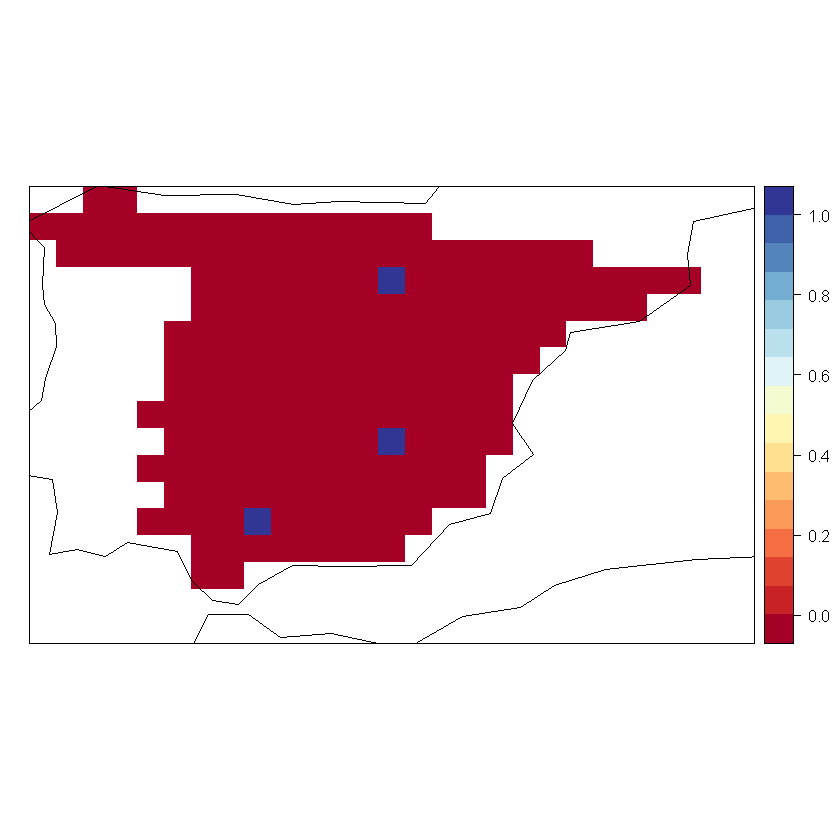

In [25]:
bimodalesOrNot_clim <- quantity2clim(quantity = df.fireSeason$'Bimodal', what = 'bimodales', ref.grid = grid, backperm = NULL)
spatialPlot(bimodalesOrNot_clim, backdrop.theme = 'coastline')

#### Seasonal Concentration

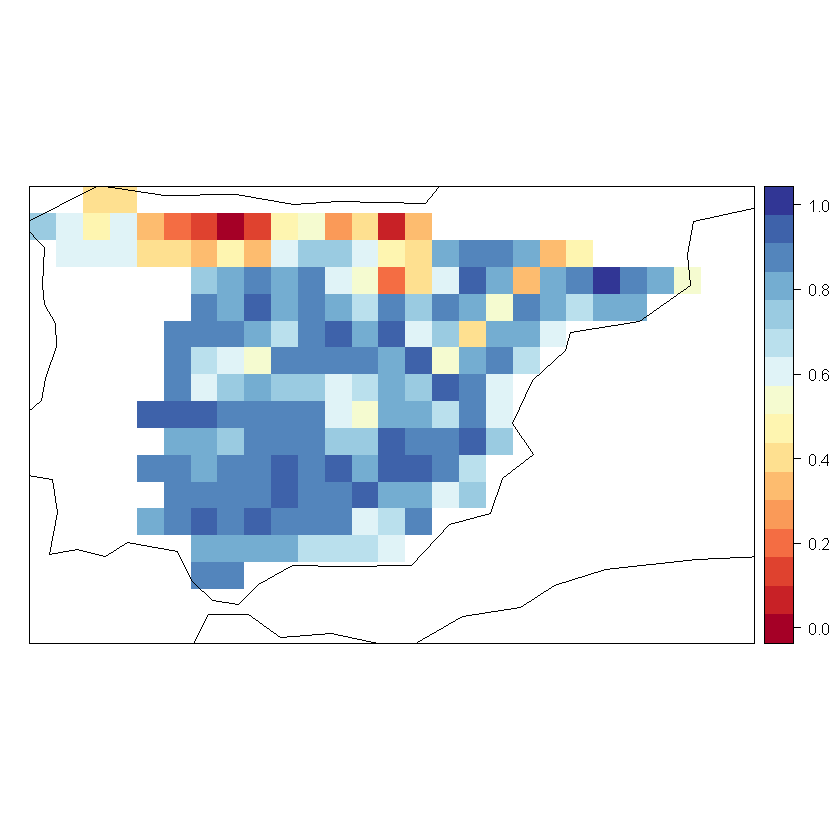

In [26]:
SeasonalConcentration_viz <- quantity2clim(quantity = df.fireSeason$'SeasonalConcentration', what = 'SeasonalConcentration', ref.grid = grid, backperm = NULL)
spatialPlot(SeasonalConcentration_viz, backdrop.theme = 'coastline')

#### Seasonal Timing

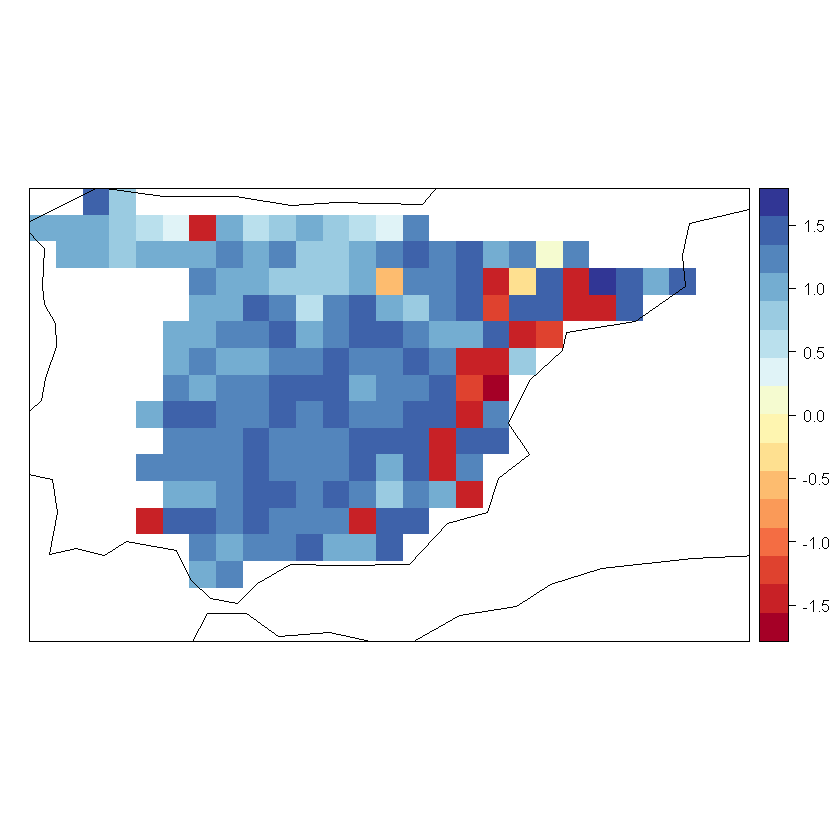

In [27]:
SeasonalTiming_viz <- quantity2clim(quantity = df.fireSeason$'SeasonalTiming', what = 'SeasonalTiming', ref.grid = grid, backperm = NULL)
spatialPlot(SeasonalTiming_viz, backdrop.theme = 'coastline')

# Clustering Analysis of Fire Season Patterns

In this section, we perform cluster analysis on the fire season characteristics to uncover spatial groups with similar fire season behaviors:

- `analisis_clustering_fireSeason` is used for exploratory analysis to select the optimal number of clusters, using visual tools like the elbow method and dendrograms.
- `clustering_fireSeason` applies k-means clustering with the chosen number of clusters (here, 5) to classify each spatial unit according to its fire season profile.
- The cluster results are mapped back to the spatial grid with `quantity2clim`.
- We then visualize the spatial distribution of the identified clusters using `spatialPlot` overlaid with coastlines for geographic reference.

This approach helps detect and interpret spatial patterns and regimes in fire seasonality.


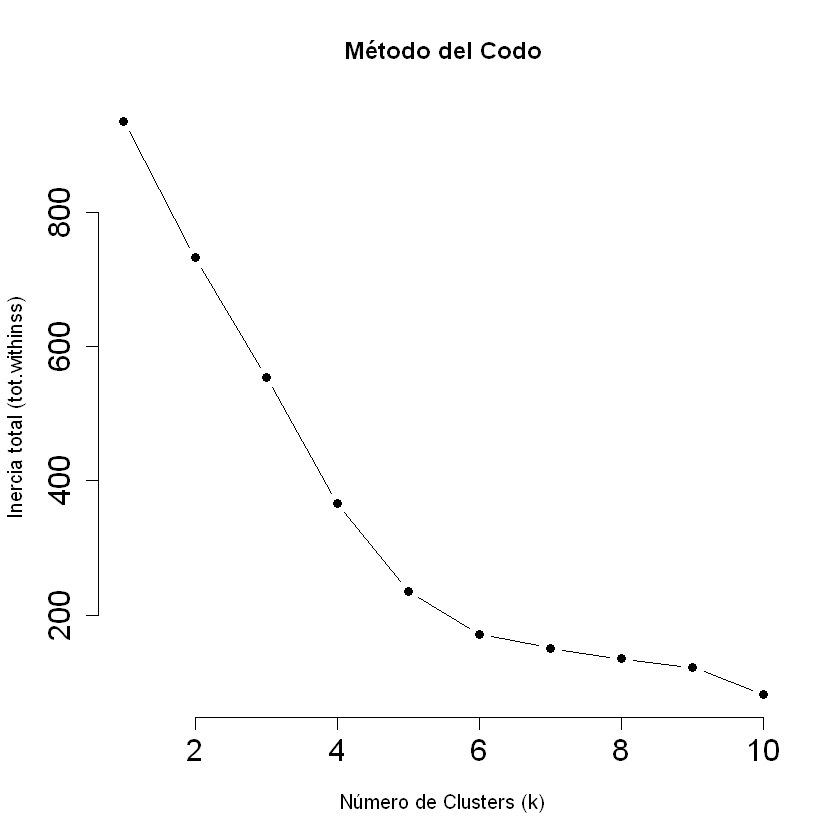

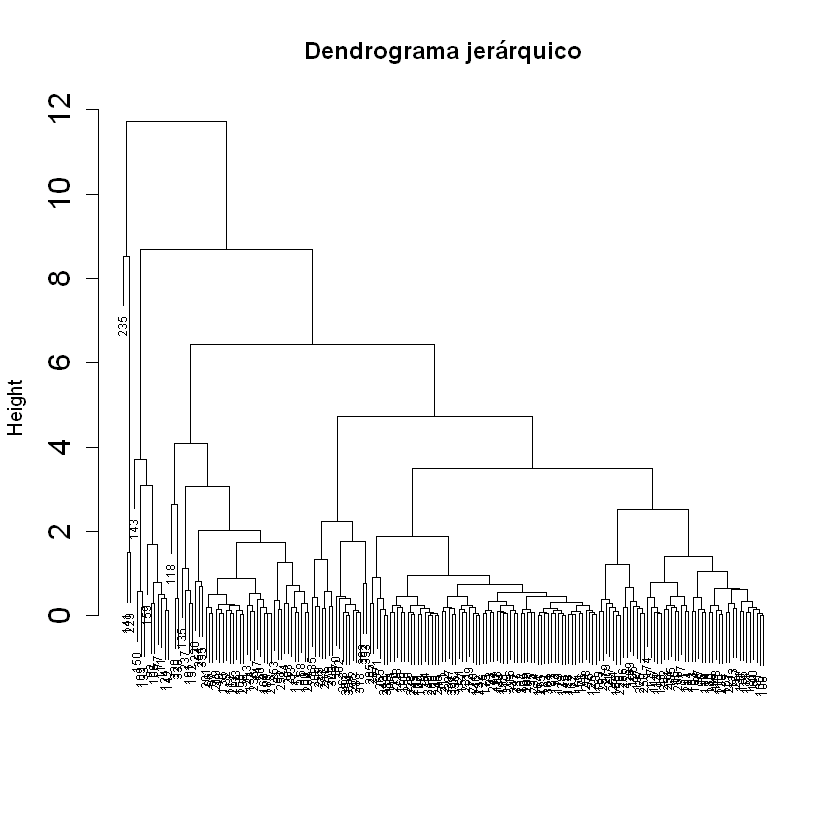

In [28]:
analisis_clustering_fireSeason(df.fireSeason)

In [31]:
clustering <- clustering_fireSeason(df = df.fireSeason, k = 5) 

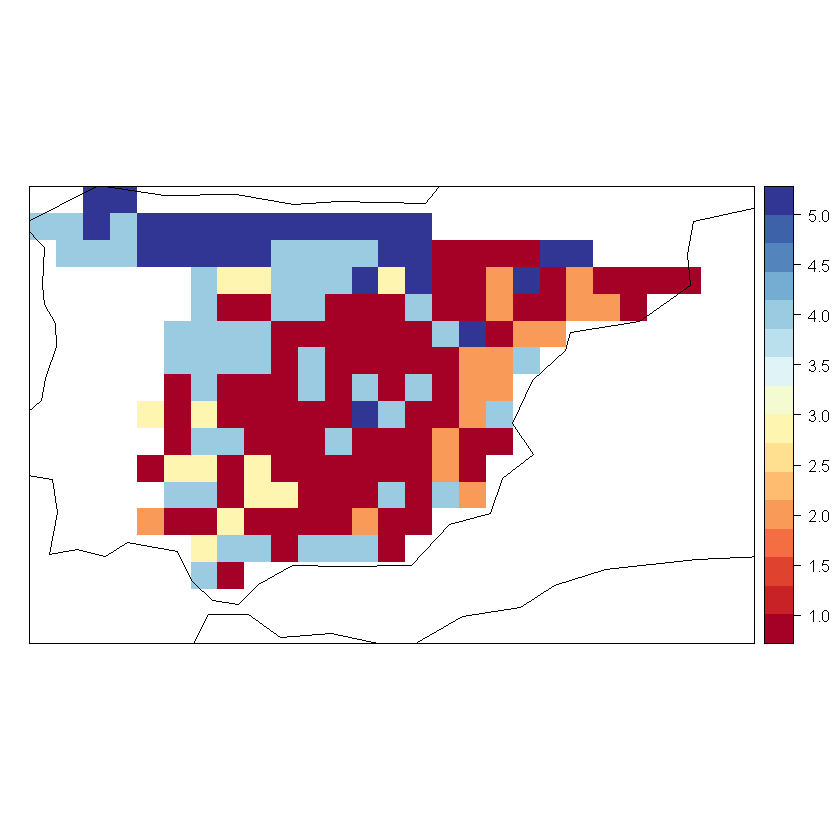

In [32]:
clustering_clim_viz <- quantity2clim(quantity = clustering$'Cluster', what = 'clustering', ref.grid = grid, backperm = NULL)
spatialPlot(clustering_clim_viz, backdrop.theme = 'coastline')